# Student Performance Prediction — ML Regression Model

**Objective:** Predict student math exam scores using demographic
and academic preparation features.

**Dataset:** Kaggle Student Performance dataset — 1,000 real student
records, 7 features including gender, parental education level,
lunch type, test preparation course, reading and writing scores.

**Models Evaluated:** Linear Regression, Ridge Regression, Random Forest

**Best Model:** Ridge Regression — R² of 0.88, RMSE of 5.32

**Key Finding:** Reading score and writing score are the strongest
predictors of math performance. Test preparation course completion
showed measurable positive impact on predicted scores.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [29]:
df = pd.read_csv('StudentsPerformance.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 8)

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [30]:
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nBasic stats:")
df.describe()

Missing values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Data types:
 gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Basic stats:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [31]:
df_encoded = df.copy()

categorical_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoding done.")
df_encoded.head()

Encoding done.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [32]:
# Target: math score (predicting math performance)
# Features: everything else

X = df_encoded.drop('math score', axis=1)
y = df_encoded['math score']

print("Features:", X.columns.tolist())
print("Target: math score")
print("Dataset size:", X.shape)

Features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']
Target: math score
Dataset size: (1000, 7)


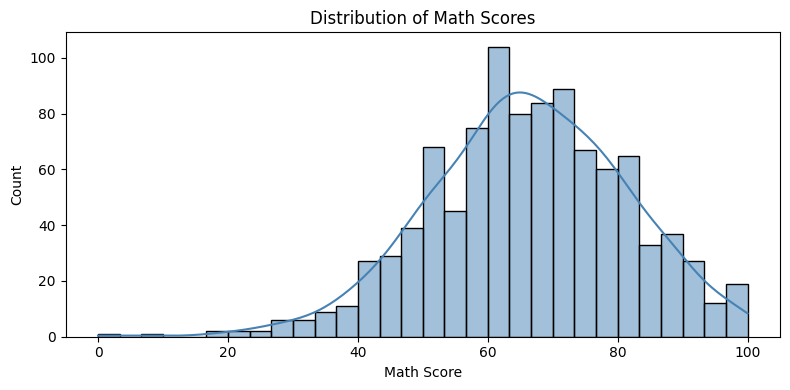

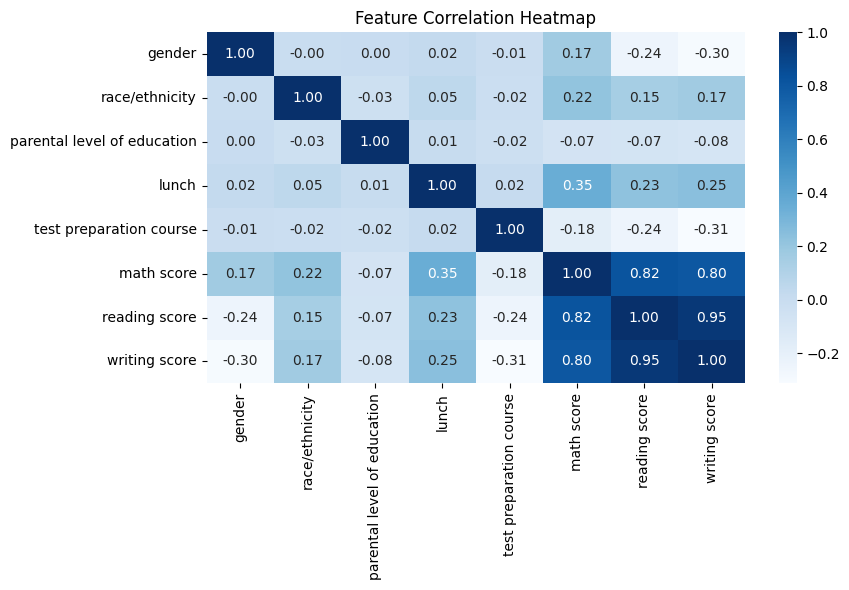

In [33]:
# Distribution of math scores
plt.figure(figsize=(8,4))
sns.histplot(y, bins=30, kde=True, color='steelblue')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.tight_layout()
plt.savefig('score_distribution.png')
plt.show()

# Correlation heatmap
plt.figure(figsize=(9,6))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set:     {X_test_scaled.shape}")

Training set: (800, 7)
Test set:     (200, 7)


In [35]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200,
                             max_depth=8,
                             random_state=42
                         )
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    cv   = cross_val_score(
               model, X_train_scaled, y_train,
               cv=5, scoring='r2'
           ).mean()

    results[name] = {
        'R2':   round(r2,   4),
        'RMSE': round(rmse, 4),
        'CV_R2':round(cv,   4)
    }
    print(f"{name:25} | R²: {r2:.4f} | RMSE: {rmse:.4f} | CV R²: {cv:.4f}")

results_df = pd.DataFrame(results).T
print("\n", results_df)

Linear Regression         | R²: 0.8838 | RMSE: 5.3175 | CV R²: 0.8573
Ridge Regression          | R²: 0.8838 | RMSE: 5.3173 | CV R²: 0.8573
Random Forest             | R²: 0.8567 | RMSE: 5.9059 | CV R²: 0.8388

                        R2    RMSE   CV_R2
Linear Regression  0.8838  5.3175  0.8573
Ridge Regression   0.8838  5.3173  0.8573
Random Forest      0.8567  5.9059  0.8388


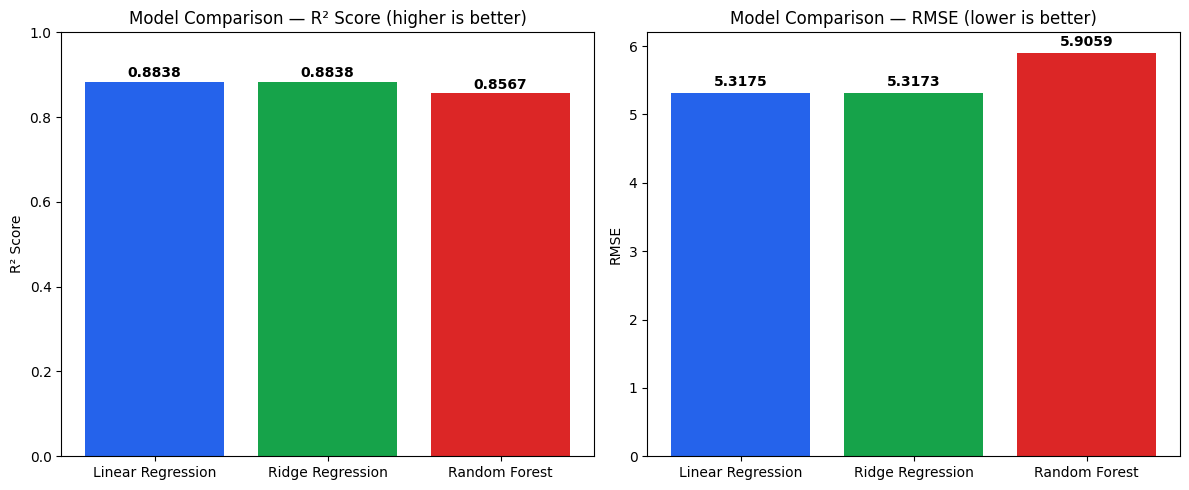

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2563EB', '#16A34A', '#DC2626']

axes[0].bar(results_df.index, results_df['R2'], color=colors)
axes[0].set_title('Model Comparison — R² Score (higher is better)')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results_df['R2']):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontweight='bold')

axes[1].bar(results_df.index, results_df['RMSE'], color=colors)
axes[1].set_title('Model Comparison — RMSE (lower is better)')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

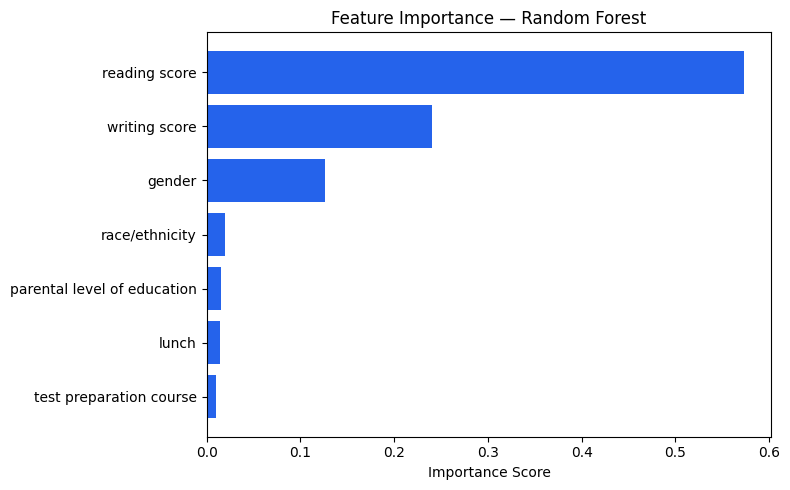

                       Feature  Importance
5                reading score    0.573570
6                writing score    0.239955
0                       gender    0.126225
1               race/ethnicity    0.020122
2  parental level of education    0.015404
3                        lunch    0.014698
4      test preparation course    0.010027


In [37]:
rf_model = models['Random Forest']

importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='#2563EB')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(importance_df.sort_values('Importance', ascending=False))

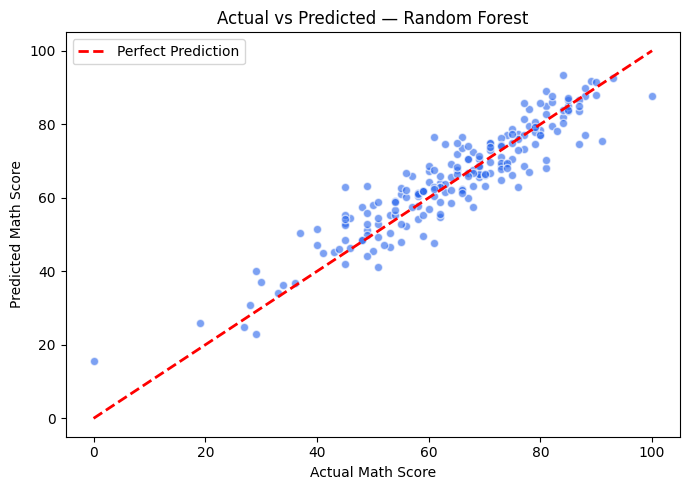

In [38]:
rf_preds = models['Random Forest'].predict(X_test_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_preds, alpha=0.6,
            color='#2563EB', edgecolors='white')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()